# <font color=darkblue>**Universidad Nacional Autónoma de México**
# <font color=darkblue>**Facultad de Ciencias**
# <font color=orange>**Práctica computacional 1 de Análisis Numérico, semestre 2026-2**
## Alumnos:
# Galán Resendiz Andres Roberto
# Valentino Hernández Gael Emiliano

## **Aritmética de punto flotante y número de condición**

### Objetivos de aprendizaje

Al finalizar esta práctica el estudiante será capaz de:

- Comprender los efectos de la aritmética de punto flotante en cálculos numéricos.
- Analizar errores absolutos y relativos en aproximaciones numéricas.
- Implementar algoritmos numéricos evitando cancelación catastrófica.
- Identificar límites del sistema de representación IEEE.
- Analizar el número de condición y su relación con la estabilidad numérica.

---

### Indicaciones generales

- La práctica es **equipo maximo 2 personas**.
- Todos los resultados deben ir acompañados de **análisis numérico**.
- Se debe comentar el código claramente.
- No se evaluará únicamente el resultado, sino la interpretación de los fenómenos observados.

# Ejercicio 1 — Aproximación del número de Euler

El número de Euler puede definirse mediante el límite

$$
e = \lim_{n\to\infty}\left(1+\frac{1}{n}\right)^n.$$

### Actividad

1. Escriba un programa que calcule

$$
\left(1+\frac{1}{n}\right)^n
$$

para $ n = 10^k $, con $ k=0,1,2,\dots,20 $.

2. Construya una tabla que incluya:

- $n$
- aproximación obtenida
- error absoluto
- error relativo

usando como referencia el valor de `exp(1)`.

3. Realice los cálculos en doble precisión (`float64`).


### Preguntas de análisis

- ¿Cómo evoluciona la aproximación conforme \(n\) crece?
- ¿Por qué los errores dejan de disminuir después de cierto punto?
- Relacione el comportamiento observado con el redondeo en punto flotante.


In [ ]:
import numpy as np

def ejercicio_euler():
    e_referencia = np.exp(1)
    print(f"{'k':>2} | {'n':>10} | {'Aproximación':>20} | {'Error Absoluto':>15} | {'Error Relativo':>15}")
    print("-" * 75)
    for k in range(21):
        n = 10**k
        aproximacion = (1 + 1/n)**n
        error_abs = abs(e_referencia - aproximacion)
        error_rel = error_abs / e_referencia
        print(f"{k:2d} | 10^{k:<8} | {aproximacion:20.15f} | {error_abs:15.5e} | {error_rel:15.5e}")

ejercicio_euler()

 k |          n |         Aproximación |  Error Absoluto |  Error Relativo
---------------------------------------------------------------------------
 0 | 10^0        |    2.000000000000000 |     7.18282e-01 |     2.64241e-01
 1 | 10^1        |    2.593742460100002 |     1.24539e-01 |     4.58155e-02
 2 | 10^2        |    2.704813829421528 |     1.34680e-02 |     4.95460e-03
 3 | 10^3        |    2.716923932235594 |     1.35790e-03 |     4.99542e-04
 4 | 10^4        |    2.718145926824926 |     1.35902e-04 |     4.99954e-05
 5 | 10^5        |    2.718268237192297 |     1.35913e-05 |     4.99995e-06
 6 | 10^6        |    2.718280469095753 |     1.35936e-06 |     5.00082e-07
 7 | 10^7        |    2.718281694132082 |     1.34327e-07 |     4.94161e-08
 8 | 10^8        |    2.718281798347358 |     3.01117e-08 |     1.10775e-08
 9 | 10^9        |    2.718282052011560 |     2.23553e-07 |     8.22404e-08
10 | 10^10       |    2.718282053234788 |     2.24776e-07 |     8.26904e-08
11 | 10^11   

1. ¿CÓMO EVOLUCIONA LA APROXIMACIÓN CONFORME 'n' CRECE?
   - De k=0 a k=8, la aproximación mejora y se acerca al valor real (2.71828...).
   - De k=9 a k=15, el error deja de bajar y empieza a oscilar ligeramente.
   - De k=16 en adelante, la aproximación colapsa a 1.000000 y se aleja totalmente.

2. ¿POR QUÉ LOS ERRORES DEJAN DE DISMINUIR DESPUÉS DE CIERTO PUNTO?
   - Por el limite de precision de la computadora en formato float64, cuando 'n' es muy grande (10^16), el valor de '1/n' es menor que el epsilon de la máquina.
   - Al intentar sumar 1 + 10^-16, la computadora no tiene suficientes bits para
     mantener esa diferencia y redondea el resultado a 1 exacto.

3. RELACIÓN CON EL REDONDEO EN PUNTO FLOTANTE:
   - Este ejercicio muestra el conflicto entre el error de truncamiento
     y el error de redondeo.
   - Mientras el error matemático pide un 'n' infinito, el hardware impone un límite asi cuando n > 10^15 el error de redondeo domina por completo y destruye el cálculo.

# Ejercicio 2 — Serie de Taylor de la función exponencial

La función exponencial puede representarse mediante la serie

$$e^x = \sum_{k=0}^{\infty}\frac{x^k}{k!}$$

### Actividad

1. Implemente un algoritmo que aproxime $e^x$ usando la serie de Taylor.
2. Use el criterio de paro:

$$\frac{|x^n|}{n!} < 10^{-6}.$$

3. Procure evitar cancelaciones numéricas para valores negativos de $x$.

### Evaluación experimental

Construya una tabla con:

- aproximación obtenida,
- valor de `exp(x)` de la máquina,
- error absoluto,
- error relativo,

para:

$$x = \pm20,\ \pm15,\ \pm10,\ \pm5,\ \pm1$$

### Preguntas de análisis

- ¿Qué ocurre cuando $x$ es negativo?
- ¿Por qué la serie directa puede volverse inestable?
- ¿Qué estrategia utilizó para mejorar la estabilidad?


In [ ]:
import numpy as np

def taylor_ex(x, tolerancia=1e-6):
    x_original = x
    es_negativo = x < 0
    if es_negativo:
        x = abs(x)
    termino = 1.0
    suma_taylor = termino
    n = 1
    while True:
        termino = (termino * x) / n
        suma_taylor += termino
        if abs(termino) < tolerancia:
            break
        n += 1
    resultado = 1 / suma_taylor if es_negativo else suma_taylor
    return resultado
valores_x = [20, -20, 15, -15, 10, -10, 5, -5, 1, -1]
print("="*100)
print(f"{'x':>5} | {'Aprox. Taylor':>18} | {'exp(x) Máquina':>18} | {'Error Absoluto':>15} | {'Error Relativo':>15}")
print("-" * 100)
for x in valores_x:
    aprox = taylor_ex(x)
    real = np.exp(x)
    err_abs = abs(real - aprox)
    err_rel = err_abs / abs(real) if real != 0 else 0
    print(f"{x:5d} | {aprox:18.10e} | {real:18.10e} | {err_abs:15.5e} | {err_rel:15.5e}")

    x |      Aprox. Taylor |     exp(x) Máquina |  Error Absoluto |  Error Relativo
----------------------------------------------------------------------------------------------------
   20 |   4.8516519541e+08 |   4.8516519541e+08 |     2.38419e-07 |     4.91417e-16
  -20 |   2.0611536224e-09 |   2.0611536224e-09 |     8.27181e-25 |     4.01319e-16
   15 |   3.2690173725e+06 |   3.2690173725e+06 |     2.46335e-07 |     7.53544e-14
  -15 |   3.0590232050e-07 |   3.0590232050e-07 |     2.30287e-20 |     7.52812e-14
   10 |   2.2026465795e+04 |   2.2026465795e+04 |     2.56397e-07 |     1.16404e-11
  -10 |   4.5399929763e-05 |   4.5399929762e-05 |     5.28467e-16 |     1.16403e-11
    5 |   1.4841315898e+02 |   1.4841315910e+02 |     1.19807e-07 |     8.07254e-10
   -5 |   6.7379470045e-03 |   6.7379469991e-03 |     5.43923e-12 |     8.07254e-10
    1 |   2.7182818011e+00 |   2.7182818285e+00 |     2.73127e-08 |     1.00478e-08
   -1 |   3.6787944487e-01 |   3.6787944117e-01 |     3.696

1. ¿QUÉ OCURRE CUANDO 'x' ES NEGATIVO?
   - Si se usa la serie de Taylor directa con números negativos los términos
     alternan su signo (+, -, +, -) causando que se resten números muy
     grandes entre sí para obtener un resultado final muy pequeño.

2. ¿POR QUÉ LA SERIE DIRECTA PUEDE VOLVERSE INESTABLE?
   - Debido a la cancelacion catastrofica al restar valores grandes
     que son casi iguales los errores de redondeo en los últimos dígitos
     se vuelven significativos destruyendo la precisión del resultado.

3. ¿QUÉ ESTRATEGIA SE UTILIZÓ PARA MEJORAR LA ESTABILIDAD?
   - Se aplica la e^(-x) = 1 / e^(x).
   - En lugar de calcular la serie con términos negativos calculamos la serie
     para el valor positivo y al final dividimos 1 entre ese resultado para mantener la precisión en todos los casos.

# Ejercicio 3 — Épsilon de máquina

La épsilon de máquina es el número positivo más pequeño que cumple:

$$1+\varepsilon > 1.$$

### Actividad

1. Investigue cómo obtener la épsilon de máquina en Python.
2. Implemente un programa que la calcule experimentalmente.
3. Calcule también:

$$\epsilon = |3(4/3 - 1) - 1|$$

### Preguntas de análisis

- Explique por qué el valor obtenido coincide con la épsilon de máquina.
- ¿Qué papel juega el redondeo?
- ¿El resultado sería el mismo en un sistema de base 3? Justifique.



In [ ]:
import sys
print("Obtenemos el epcilon con python")
eps_sistema = sys.float_info.epsilon
print(f"Épsilon oficial (sys.float_info.epsilon): {eps_sistema}")
print("Calculado experimentalmente")
def calcular_epsilon():
    epsilon = 1.0
    while (1.0 + epsilon) > 1.0:
        ultimo_valido = epsilon
        epsilon = epsilon / 2.0
    return ultimo_valido
eps_exp = calcular_epsilon()
print(f"Épsilon calculado experimentalmente:    {eps_exp}")
print("Calculado por: |3 * (4/3 - 1) - 1|")
eps_formula = abs(3 * (4/3 - 1) - 1)
print(f"Resultado de la fórmula:                {eps_formula}")

Obtenemos el epcilon con python
Épsilon oficial (sys.float_info.epsilon): 2.220446049250313e-16
Calculado experimentalmente
Épsilon calculado experimentalmente:    2.220446049250313e-16
Calculado por: |3 * (4/3 - 1) - 1|
Resultado de la fórmula:                2.220446049250313e-16


1. ¿POR QUÉ EL VALOR COINCIDE CON LA ÉPSILON DE MÁQUINA?

     - La coincidencia ocurre porque el número 4/3 no tiene una representación exacta en sistema binario al almacenarlo en la memoria de la computadora se genera un error de redondeo y al hacer la operación propuesta, estamosacando ese error residual, que por definición es el épsilon de máquina.

2. ¿QUÉ PAPEL JUEGA EL REDONDEO?

     - El redondeo es lo que nos da imprecision Las computadoras usan el estándar IEEE 754 que tiene una mantisa limitada que hace que todo número que requiera más bits es redondeado al valor representable más cercano, asi el épsilon es la medida de esa distancia mínima de redondeo cuando trabajamos cerca del valor 1.0.

3. ¿EL RESULTADO SERÍA EL MISMO EN UN SISTEMA DE BASE 3?

     - No, n un sistema de base 3, el número 4/3 es exactamente 1.1_3. Al ser una representación finita y exacta, no habría error de redondeo en la operación (4/3 - 1), el resultado de toda la expresión sería exactamente 0 y no el épsilon de esa máquina, ya que no habría residuo por representar.

# Ejercicio 4 — Overflow en precisión sencilla

Considere la sucesión

$$x_{n+1}=4x_n,\qquad x_0=1$$

### Actividad

1. Realice los cálculos usando precisión sencilla (`float32`).
2. Implemente un ciclo que actualice el valor de la sucesión.
3. Detenga el proceso cuando:
$$x_{n+1} \le x_n$$

4. Muestre los resultados en forma de tabla.

### Preguntas de análisis

- ¿Por qué la condición de paro no ocurre en aritmética real?
- ¿Qué fenómeno del estándar IEEE explica lo observado?
- ¿Cuántas iteraciones fueron necesarias?
- ¿Cuál fue el último valor representable?

In [ ]:
import numpy as np
import pandas as pd
x_n = np.float32(1.0)
datos = []
n = 0
print("Ejecutando sucesión x_{n+1} = 4 * x_n en float32...\n")
while True:
    datos.append({'n': n, 'valor': x_n})
    x_next = np.float32(4.0 * x_n)
    if x_next <= x_n:
        datos.append({'n': n + 1, 'valor': x_next})
        break
    x_n = x_next
    n += 1
df = pd.DataFrame(datos)
pd.set_option('display.max_rows', 20)
print(df)

ultimo_val = df.iloc[-2]['valor']
iteraciones = n

Ejecutando sucesión x_{n+1} = 4 * x_n en float32...

     n         valor
0    0  1.000000e+00
1    1  4.000000e+00
2    2  1.600000e+01
3    3  6.400000e+01
4    4  2.560000e+02
..  ..           ...
61  61  5.316912e+36
62  62  2.126765e+37
63  63  8.507059e+37
64  64           inf
65  65           inf

[66 rows x 2 columns]


/tmp/ipython-input-207/1441903821.py:16: RuntimeWarning: overflow encountered in scalar multiply
  x_next = np.float32(4.0 * x_n)


1. ¿Por qué la condición de paro no ocurre en aritmética real?
    - Pues ya que la sucesión $x_{n+1} = 4x_n$ es una progresión geométrica que tiende al infinito ($4^n$) entonces no pasa que se detenga ni que disminuya porque siempre multiplicas por un número mayor a 1.
2. ¿Qué fenómeno del estándar IEEE explica lo observado?
    - Se trata del Overflow, ya que el estándar IEEE para float32 tiene un límite máximo que puede representar, entonces cuando el cálculo supera este límite, el sistema devuelve un valor especial llamado inf que representa al infinito y como inf no es mayor que inf, la condición x_next <= x_n se vuelve verdadera y el ciclo se detiene.
3. ¿Cuántas iteraciones fueron necesarias?
    - 64
4. ¿Cuál fue el último valor representable?
    - 8.507059e+37

# Ejercicio 5 — Número de condición y matriz de Hilbert

La matriz de Hilbert se define como

$$
H^{(n)}_{ij}=\frac{1}{i+j-1}$$

### Actividad

1. Implemente un programa que genere $H^{(n)}$.
2. Calcule el número de condición para $n=1,2,\dots,30$.
3. Construya una tabla con los resultados.
### Visualización

Grafique el número de condición en función de $n$ usando escala logarítmica.

### Preguntas de análisis

- ¿Cómo cambia el condicionamiento conforme aumenta $n$?
- ¿Qué implica esto para resolver sistemas lineales?
- Relacione el crecimiento observado con la estabilidad numérica.



Tabla de Números de Condición para la Matriz de Hilbert:
     n  Número de Condición
0    1         1.000000e+00
1    2         1.928147e+01
2    3         5.240568e+02
3    4         1.551374e+04
4    5         4.766073e+05
..  ..                  ...
25  26         5.825078e+18
26  27         4.414670e+18
27  28         5.889050e+18
28  29         8.060274e+18
29  30         5.512691e+18

[30 rows x 2 columns]


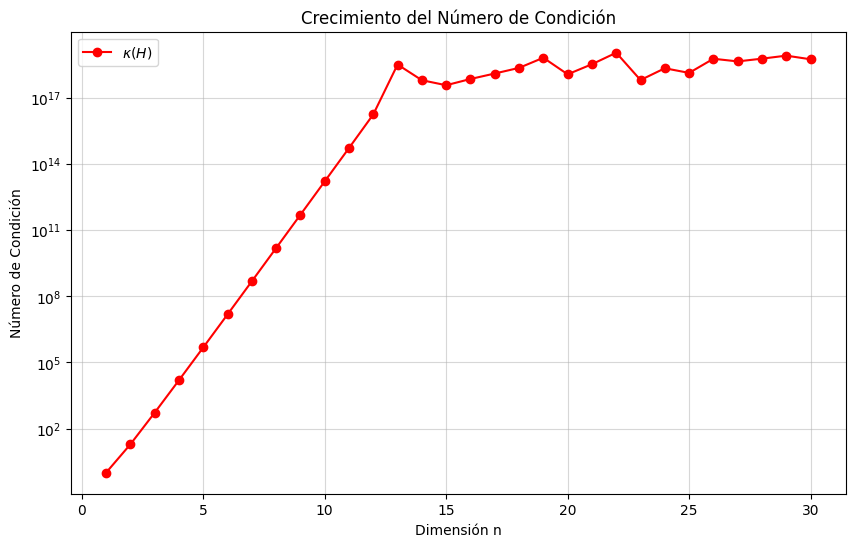

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import hilbert

n_values = range(1, 31)
cond_numbers = []
for n in n_values:
    H = hilbert(n)
    cond_p = np.linalg.cond(H)
    cond_numbers.append(cond_p)
df_hilbert = pd.DataFrame({
    'n': n_values,
    'Número de Condición': cond_numbers
})
print("Tabla de Números de Condición para la Matriz de Hilbert:")
print(df_hilbert)
plt.figure(figsize=(10, 6))
plt.semilogy(n_values, cond_numbers, 'ro-', label= r'$\kappa(H)$')
plt.title('Crecimiento del Número de Condición')
plt.xlabel('Dimensión n')
plt.ylabel('Número de Condición')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.show()

1. ¿Cómo cambia el condicionamiento conforme aumenta $n$?
     - El condicionamiento empeora de forma exponencial, al observar la gráfica podemos ver la relación casi lineal que indica que el número de condición ($\kappa$) crece extremadamente rápido, pasando de $1$ (para $n=1$) hasta superar $10^{18}$ para $n=30$.
2. ¿Qué implica esto para resolver sistemas lineales?
     - Implica que el sistema es mal condicionado, los errores en los datos se amplifican masivamente en la solución final y para valores de $n$ grandes, la computadora pierde la capacidad de distinguir la solución real del ruido numérico.
3. Relacione el crecimiento observado con la estabilidad numérica.
     - Existe una pérdida directa de estabilida ya que el número de dígitos significativos correctos en la solución disminuye a medida que $\kappa(H)$ aumenta y como la precisión de un float64 es de unos 16 dígitos y el número de condición para $n=30$ supera $10^{18}$, el error de redondeo supera a la señal, haciendo que el cálculo sea numéricamente inestable y el resultado carezca de sentido.

## Conclusiones generales
  Despues de hacer esta practiva podemos darnos cuenta de que el redondeo no es un error menor, sino un factor crítico en el cómputo científico, en sistemas finitos, los números no pueden representarse con precisión infinita, lo que introduce pequeños errores que pueden amplificarse catastróficamente, un ejemplo de esto es el ejercicio de la matriz de Hilbert, donde el número de condición ($\kappa$) creció exponencialmente hasta superar $10^{18}$,haciendo que la maquina ya no funcione y esto no ayuda mucho a la hora de llevar cosas a la practica, ademas es fundamental distinguir entre condicionamiento y estabilidad ya que mientras que el condicionamiento es una propiedad intrínseca del problema, la estabilidad depende del algoritmo y de la aritmética utilizada para resolverlo, la aritmética de punto flotante impone límites físicos, como el overflow, donde el sistema simplemente deja de representar valores numéricos para devolver inf, entonces para garantizar resultados confiables, debemos de saber elegir y analisar algoritmos que sean eficientes pero también entender las limitaciones del estándar IEEE y es importante saber que un problema mal condicionado hará que incluso el algoritmo más estable falle ante el inevitable error de redondeo.